In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dataset/housing.csv")
df.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,location,year,price
0,7420,4,2,3,yes,no,yes,no,yes,2,Urban,2019,13300000
1,8960,4,4,4,yes,no,no,no,yes,3,Urban,2020,12250000
2,9960,3,2,2,yes,no,yes,no,no,2,Semi-Urban,2018,12250000
3,7500,4,2,2,yes,no,yes,no,yes,3,Urban,2021,12215000
4,7420,4,1,2,yes,yes,yes,no,yes,2,Urban,2022,11410000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   area             31 non-null     int64 
 1   bedrooms         31 non-null     int64 
 2   bathrooms        31 non-null     int64 
 3   stories          31 non-null     int64 
 4   mainroad         31 non-null     object
 5   guestroom        31 non-null     object
 6   basement         31 non-null     object
 7   hotwaterheating  31 non-null     object
 8   airconditioning  31 non-null     object
 9   parking          31 non-null     int64 
 10  location         31 non-null     object
 11  year             31 non-null     int64 
 12  price            31 non-null     int64 
dtypes: int64(7), object(6)
memory usage: 3.3+ KB


In [4]:
df.isnull().sum()

area               0
bedrooms           0
bathrooms          0
stories            0
mainroad           0
guestroom          0
basement           0
hotwaterheating    0
airconditioning    0
parking            0
location           0
year               0
price              0
dtype: int64

In [5]:
df.describe()

,area,bedrooms,bathrooms,stories,parking,year,price
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,3.100000e+01
mean,7476.935484,3.451613,1.935484,2.096774,1.709677,2019.774194,9.616258e+06
std,2476.288781,0.567962,0.727346,0.870051,0.642575,1.606439,1.361852e+06
min,3500.000000,3.000000,1.000000,1.000000,0.000000,2017.000000,8.290000e+06
25%,6000.000000,3.000000,1.500000,2.000000,1.000000,2018.500000,8.645000e+06
50%,7420.000000,3.000000,2.000000,2.000000,2.000000,2020.000000,9.100000e+06
75%,8300.000000,4.000000,2.000000,2.000000,2.000000,2021.000000,1.001000e+07
max,16200.000000,5.000000,4.000000,4.000000,3.000000,2022.000000,1.330000e+07


In [6]:
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning']

for col in binary_cols:
    df[col] = df[col].map({'yes':1,'no':0})

In [7]:
df['location'] = df['location'].map({
    'Urban':2,
    'Semi-Urban':1,
    'Rural':0
})

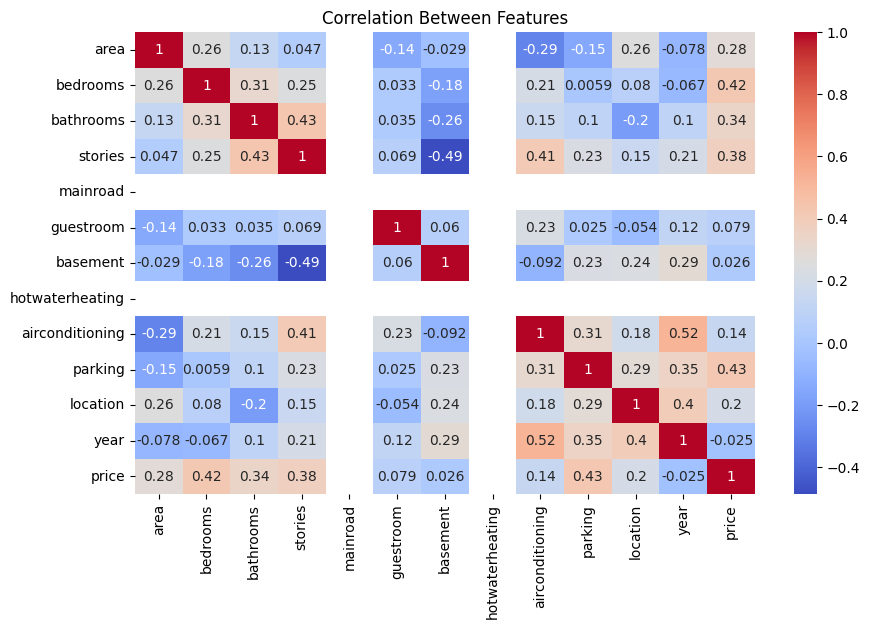

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Features")
plt.show()

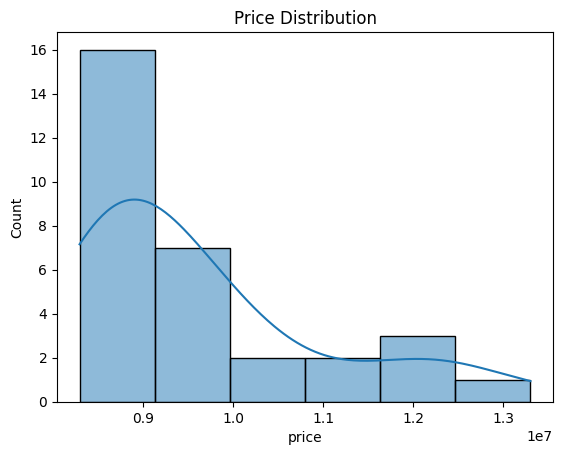

In [9]:
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

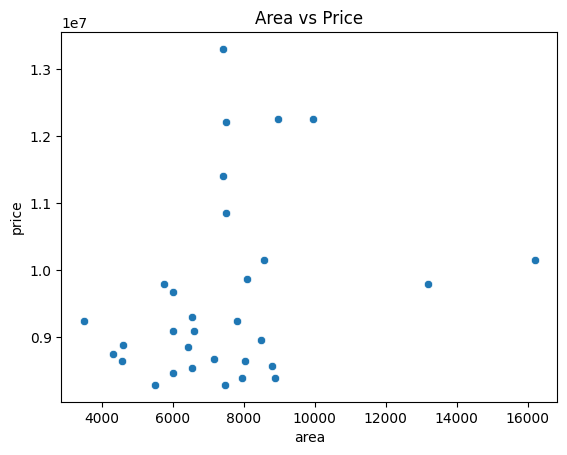

In [10]:
sns.scatterplot(x='area', y='price', data=df)
plt.title("Area vs Price")
plt.show()

In [11]:
X = df[['area','bedrooms','bathrooms','stories','parking',
        'mainroad','guestroom','basement','hotwaterheating','airconditioning','location']]

y = df['price']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))

R2 Score: -2.049554518606105
MAE: 910456.623531535
MSE: 1041575345829.9152


In [16]:
import joblib

joblib.dump(model, "model/model.pkl")
joblib.dump(scaler, "model/scaler.pkl")

['model/scaler.pkl']